# MGF Extrapolation Test

Test trained model on data with wider theta distribution.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import lognorm
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from src.mgf_dataset import generate_ou_process_variable_theta

ImportError: cannot import name 'generate_ou_process_variable_theta' from 'src.mgf_dataset' (/Users/jami/Documents/Research/URAD 26W/transformer-causal-dynamics/src/mgf_dataset.py)

## 1. Load Model and Training Data Config

In [ ]:
# Load config and model
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

print(f"✓ Model loaded from {model_path}")
print(f"✓ Device: {device}")

✓ Model loaded from ../experiments/model_mgf.pth
✓ Device: cpu


In [ ]:
# Load training data to get original theta distribution
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
train_data = torch.load(data_path, weights_only=False)

theta_train = train_data['theta_values'].numpy()
trajectories_train = train_data['trajectories']
s_range = train_data['s_range']

print(f"\nTraining data:")
print(f"  Samples: {len(theta_train)}")
print(f"  Theta range: [{theta_train.min():.3f}, {theta_train.max():.3f}]")
print(f"  Theta mean: {theta_train.mean():.3f} ± {theta_train.std():.3f}")


Training data:
  Samples: 10000
  Theta range: [0.018, 49.408]
  Theta mean: 1.641 ± 2.162


## 2. Generate Test Data with Wider Theta Distribution

In [ ]:
# Extrapolation parameter - CHANGE THIS TO TEST DIFFERENT WIDTHS
THETA_STD_MULTIPLIER = 5.0  # Scale the std by this factor

# Get training config
theta_mean = cfg['theta_sampling']['mean']
theta_sigma = cfg['theta_sampling']['sigma']
theta_sigma_test = theta_sigma * THETA_STD_MULTIPLIER

# Other parameters
num_test = 2000
sequence_length = cfg['generation']['sequence_length']
mu = cfg['physics']['mu']
dt = cfg['physics']['dt']
stationary_var = cfg['physics']['stationary_variance']

print(f"Generating test data:")
print(f"  Training theta std: {theta_sigma}")
print(f"  Testing theta std: {theta_sigma_test} ({THETA_STD_MULTIPLIER}x)")
print(f"  Samples: {num_test}")

Generating test data:
  Training theta std: 0.5
  Testing theta std: 2.5 (5.0x)
  Samples: 2000


In [ ]:
# Sample theta from wider distribution
theta_test = np.random.lognormal(mean=theta_mean, sigma=theta_sigma_test, size=num_test)

# Use FIXED D (not fixed stationary variance)
D_fixed = cfg['physics']['D']
D_test = np.full(num_test, D_fixed)

# Generate trajectories
trajectories_test, theta_tensor_test = generate_ou_process_variable_theta(
    batch_size=num_test,
    time_steps=sequence_length,
    theta_values=theta_test,
    mu=mu,
    D_values=D_test,
    dt=dt
)

# Compute actual stationary variances (which now vary with theta)
stationary_var_test = D_test / theta_test

print(f"\n✓ Test data generated")
print(f"  Theta range: [{theta_test.min():.3f}, {theta_test.max():.3f}]")
print(f"  Theta mean: {theta_test.mean():.3f} ± {theta_test.std():.3f}")
print(f"  Fixed D: {D_fixed}")
print(f"  Stationary variance range: [{stationary_var_test.min():.3f}, {stationary_var_test.max():.3f}]")
print(f"  Stationary variance mean: {stationary_var_test.mean():.3f} ± {stationary_var_test.std():.3f}")


✓ Test data generated
  Theta range: [0.001, 6699.884]
  Theta mean: 24.564 ± 230.208
  Fixed D: 0.02
  Stationary variance range: [0.000, 36.107]
  Stationary variance mean: 0.320 ± 1.696


## 3. Test Model and Extract Moments

In [ ]:
# Helper function
def parabola(s, A, B):
    return A * s**2 + B * s

# Get predictions
with torch.no_grad():
    preds, _ = model(trajectories_test.to(device))
    phi_preds = preds[:, -1, :].cpu().numpy()

# Extract moments
trajs_test = trajectories_test.cpu().numpy().squeeze()
X_Ls = trajs_test[:, -1]

predicted_means = np.zeros(num_test)
predicted_variances = np.zeros(num_test)
theoretical_means = np.zeros(num_test)
theoretical_variances = np.zeros(num_test)

for i in range(num_test):
    # Predicted moments from parabola fit
    popt, _ = curve_fit(parabola, s_range, phi_preds[i])
    A, B = popt
    predicted_means[i] = B
    predicted_variances[i] = 2 * A
    
    # Theoretical moments with varying stationary variance
    theta_i = theta_test[i]
    D_i = D_test[i]
    X_L_i = X_Ls[i]
    stationary_var_i = D_i / theta_i
    
    exp_theta_dt = np.exp(-theta_i * dt)
    theoretical_means[i] = exp_theta_dt * X_L_i + mu * (1 - exp_theta_dt)
    theoretical_variances[i] = stationary_var_i * (1 - np.exp(-2 * theta_i * dt))

print("✓ Moment extraction complete")

✓ Moment extraction complete


## 4. Performance Analysis

In [ ]:
# Categorize by training range
train_theta_min = theta_train.min()
train_theta_max = theta_train.max()

mask_within = (theta_test >= train_theta_min) & (theta_test <= train_theta_max)
mask_outside = ~mask_within

# Compute errors
mean_errors = np.abs(predicted_means - theoretical_means)
var_errors = np.abs(predicted_variances - theoretical_variances)

print("Performance Summary:")
print(f"\nTraining range: [{train_theta_min:.3f}, {train_theta_max:.3f}]")
print(f"\nWithin training range ({mask_within.sum()} samples, {mask_within.sum()/len(theta_test)*100:.1f}%):")
if mask_within.sum() > 0:
    print(f"  Mean MAE: {mean_errors[mask_within].mean():.6f}")
    print(f"  Var MAE: {var_errors[mask_within].mean():.6f}")
    if mask_within.sum() > 1:
        print(f"  Mean R²: {np.corrcoef(theoretical_means[mask_within], predicted_means[mask_within])[0,1]**2:.4f}")
        print(f"  Var R²: {np.corrcoef(theoretical_variances[mask_within], predicted_variances[mask_within])[0,1]**2:.4f}")

print(f"\nOutside training range ({mask_outside.sum()} samples, {mask_outside.sum()/len(theta_test)*100:.1f}%):")
if mask_outside.sum() > 0:
    print(f"  Mean MAE: {mean_errors[mask_outside].mean():.6f}")
    print(f"  Var MAE: {var_errors[mask_outside].mean():.6f}")
    if mask_outside.sum() > 1:
        print(f"  Mean R²: {np.corrcoef(theoretical_means[mask_outside], predicted_means[mask_outside])[0,1]**2:.4f}")
        print(f"  Var R²: {np.corrcoef(theoretical_variances[mask_outside], predicted_variances[mask_outside])[0,1]**2:.4f}")
else:
    print(f"  No samples outside training range. Increase THETA_STD_MULTIPLIER to test extrapolation.")

Performance Summary:

Training range: [0.018, 49.408]

Within training range (1769 samples, 88.4%):
  Mean MAE: 0.012393
  Var MAE: 0.000849
  Mean R²: 0.9945
  Var R²: 0.0577

Outside training range (231 samples, 11.6%):
  Mean MAE: 0.021573
  Var MAE: 0.002357
  Mean R²: 0.9924
  Var R²: 0.2176


## 5. Visualizations

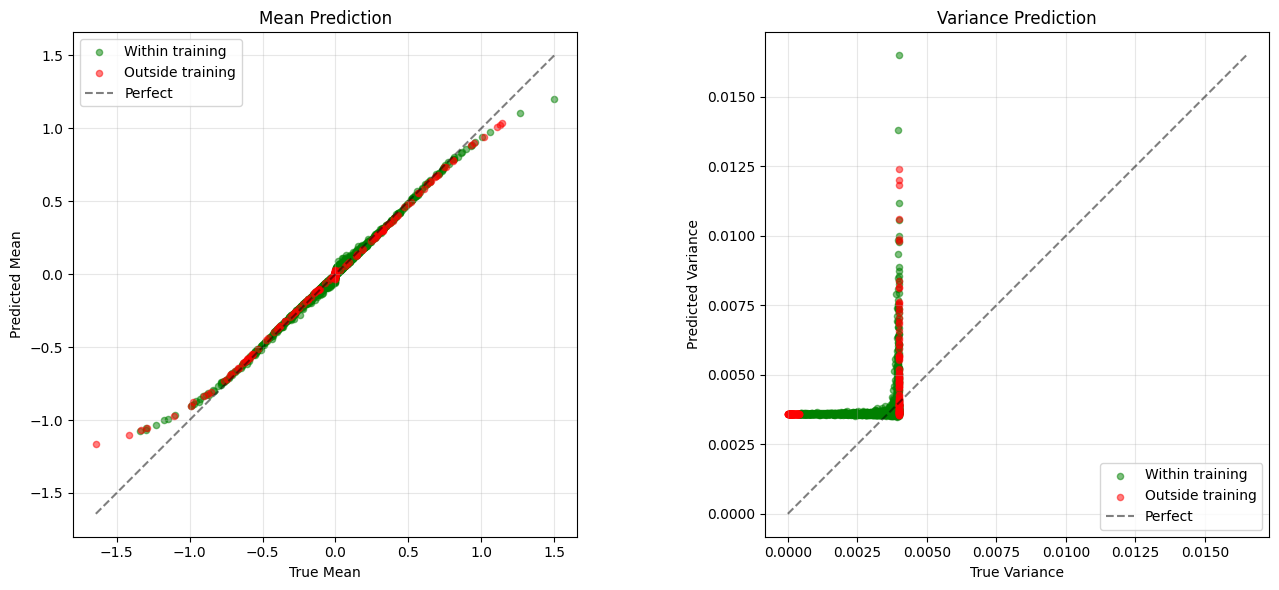

In [ ]:
# Predicted vs True
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean
ax = axes[0]
ax.scatter(theoretical_means[mask_within], predicted_means[mask_within], 
           alpha=0.5, s=20, color='green', label='Within training')
ax.scatter(theoretical_means[mask_outside], predicted_means[mask_outside], 
           alpha=0.5, s=20, color='red', label='Outside training')
lim = [min(theoretical_means.min(), predicted_means.min()),
       max(theoretical_means.max(), predicted_means.max())]
ax.plot(lim, lim, 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('True Mean')
ax.set_ylabel('Predicted Mean')
ax.set_title('Mean Prediction')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Variance
ax = axes[1]
ax.scatter(theoretical_variances[mask_within], predicted_variances[mask_within], 
           alpha=0.5, s=20, color='green', label='Within training')
ax.scatter(theoretical_variances[mask_outside], predicted_variances[mask_outside], 
           alpha=0.5, s=20, color='red', label='Outside training')
lim = [min(theoretical_variances.min(), predicted_variances.min()),
       max(theoretical_variances.max(), predicted_variances.max())]
ax.plot(lim, lim, 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('True Variance')
ax.set_ylabel('Predicted Variance')
ax.set_title('Variance Prediction')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 6. Distribution Comparison

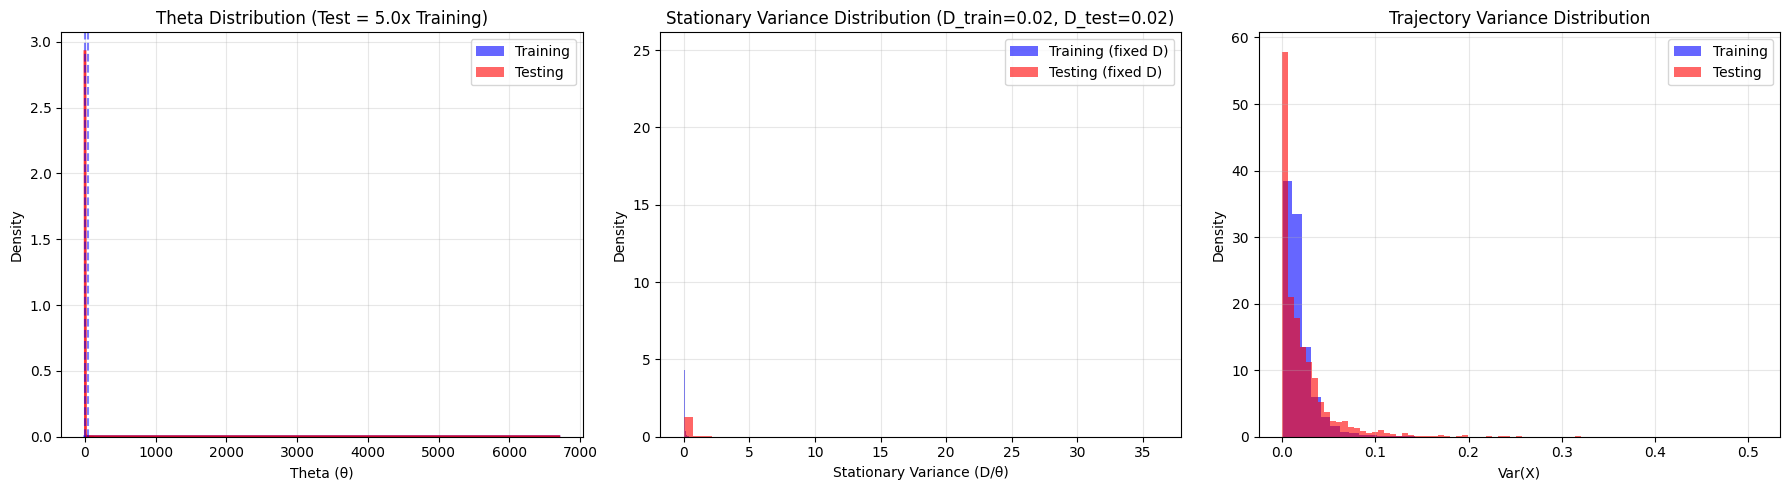


Distribution statistics:
Training - Theta: 1.641 ± 2.162
Testing  - Theta: 24.564 ± 230.208
Training - Stationary Var: 0.034 ± 0.047
Testing  - Stationary Var: 0.320 ± 1.696
Training - Var(X): 0.018 ± 0.017
Testing  - Var(X): 0.022 ± 0.030


In [ ]:
# Compute variance of trajectories
trajs_train = trajectories_train.cpu().numpy().squeeze()
var_train = np.var(trajs_train, axis=1)
var_test = np.var(trajs_test, axis=1)

# Compute stationary variance for training data
# If training used fixed D (variable stationary variance)
D_train = cfg['physics']['D']
stationary_var_train = D_train / theta_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Theta distribution
ax = axes[0]
ax.hist(theta_train, bins=50, alpha=0.6, label='Training', color='blue', density=True)
ax.hist(theta_test, bins=50, alpha=0.6, label='Testing', color='red', density=True)

# Theoretical PDFs
theta_range = np.linspace(0.01, max(theta_test.max(), theta_train.max()), 1000)
train_pdf = lognorm.pdf(theta_range, s=theta_sigma, scale=np.exp(theta_mean))
test_pdf = lognorm.pdf(theta_range, s=theta_sigma_test, scale=np.exp(theta_mean))
ax.plot(theta_range, train_pdf, 'b-', linewidth=2, alpha=0.8)
ax.plot(theta_range, test_pdf, 'r-', linewidth=2, alpha=0.8)

ax.axvline(train_theta_min, color='blue', linestyle='--', alpha=0.5)
ax.axvline(train_theta_max, color='blue', linestyle='--', alpha=0.5)
ax.set_xlabel('Theta (θ)')
ax.set_ylabel('Density')
ax.set_title(f'Theta Distribution (Test = {THETA_STD_MULTIPLIER}x Training)')
ax.legend()
ax.grid(True, alpha=0.3)

# Stationary variance distribution
ax = axes[1]
ax.hist(stationary_var_train, bins=50, alpha=0.6, label='Training (fixed D)', color='blue', density=True)
ax.hist(stationary_var_test, bins=50, alpha=0.6, label='Testing (fixed D)', color='red', density=True)
ax.set_xlabel('Stationary Variance (D/θ)')
ax.set_ylabel('Density')
ax.set_title(f'Stationary Variance Distribution (D_train={D_train}, D_test={D_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

# Trajectory variance distribution
ax = axes[2]
ax.hist(var_train, bins=50, alpha=0.6, label='Training', color='blue', density=True)
ax.hist(var_test, bins=50, alpha=0.6, label='Testing', color='red', density=True)
ax.set_xlabel('Var(X)')
ax.set_ylabel('Density')
ax.set_title('Trajectory Variance Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDistribution statistics:")
print(f"Training - Theta: {theta_train.mean():.3f} ± {theta_train.std():.3f}")
print(f"Testing  - Theta: {theta_test.mean():.3f} ± {theta_test.std():.3f}")
print(f"Training - Stationary Var: {stationary_var_train.mean():.3f} ± {stationary_var_train.std():.3f}")
print(f"Testing  - Stationary Var: {stationary_var_test.mean():.3f} ± {stationary_var_test.std():.3f}")
print(f"Training - Var(X): {var_train.mean():.3f} ± {var_train.std():.3f}")
print(f"Testing  - Var(X): {var_test.mean():.3f} ± {var_test.std():.3f}")